2025-11-05, Alexander Minidis

2025-11-06 added Support vector with optimization,

07: outlier removed

16: with/without oulier and functions moved to ML_tools

### Sediment dataset; bad models


In [1]:
from typing import Any
from pathlib import Path
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_schema import *
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.legacy.ml_tools import drop_irrelevant_columns, scale_features, remove_variance_and_correlation, output_metrics
from src.legacy.ml_tools import detect_and_remove_outliers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.svm import SVR
import xgboost as xgb
# from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd()
data_dir = working_dir / "processed_data"
database_file = data_dir / "t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)

In [3]:
# model settings
# air_data = drop_irrelevant_columns(air_data, to_drop=["None"])
# water_data = drop_irrelevant_columns(water_data, to_drop=["None"])
# soil_data = drop_irrelevant_columns(soil_data)
sediment_data = drop_irrelevant_columns(sediment_data, to_drop=["None"])

target_column = "T_half_days"
data_to_use = sediment_data.copy()
use_outlier_removal = False

## Preprocessing

In [4]:
# we will only use water data for now
X, y = data_to_use.drop(columns=[target_column]), data_to_use[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 375, number of samples: 340


In [5]:
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Any NaNs in X? {X.isna().any().any()}")
print(f"Any NaNs in y? {y.isna().any()}")
nan_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[nan_mask]
y = y[nan_mask]
print(f"After dropping NaNs: {X.shape[0]} samples remain.")

X shape: (340, 375), y shape: (340,)
Any NaNs in X? True
Any NaNs in y? False
After dropping NaNs: 334 samples remain.


### 1. Outlier detection

In [6]:
if use_outlier_removal:
    X_clean, y_clean = detect_and_remove_outliers(X, y)
    print(f"Cleaned dataset: {X_clean.shape[0]} samples, {X_clean.shape[1]} features.")
    del X, y
    X = X_clean.copy()
    y = y_clean.copy()
else:
    print("Outlier removal not applied.")

Outlier removal not applied.


### 2. Scaling/normalization

In [7]:
X_scaled = scale_features(X)
X_decorrelated = remove_variance_and_correlation(X_scaled, target_column)

Number of features: 322, number of samples: 334
Number of features: 271, number of samples: 334


## Model

In [8]:
X = X_decorrelated.copy()
y = np.log10(y)

In [9]:
# Drop rows with NaN in X or y before train/test split
nan_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[nan_mask]
y = y[nan_mask]
print(f"After dropping NaNs: {X.shape[0]} samples remain.")

After dropping NaNs: 334 samples remain.


/var/folders/f1/vq6c8bxj0bn8b9lp7sz2ms100000gn/T/ipykernel_29187/1936453274.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = X[nan_mask]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## RFR

In [11]:
# Random Forest Regressor with parameter optimization (fixed 'max_features')
rf_param_grid = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

rf = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print("Best RF parameters:", rf_grid_search.best_params_)
best_rf = rf_grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_test_exp_rf = np.power(10, y_test)
y_pred_exp_rf = np.power(10, y_pred_rf)
output_metrics(y_test_exp_rf, y_pred_exp_rf)

Best RF parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 700}
R2: 0.628
MAE: 205.498
MSE: 169845.065
RMSE: 412.123
Explained Variance: 0.661
RMSE: 412.123
Explained Variance: 0.661
RMSE: 412.123
Explained Variance: 0.661


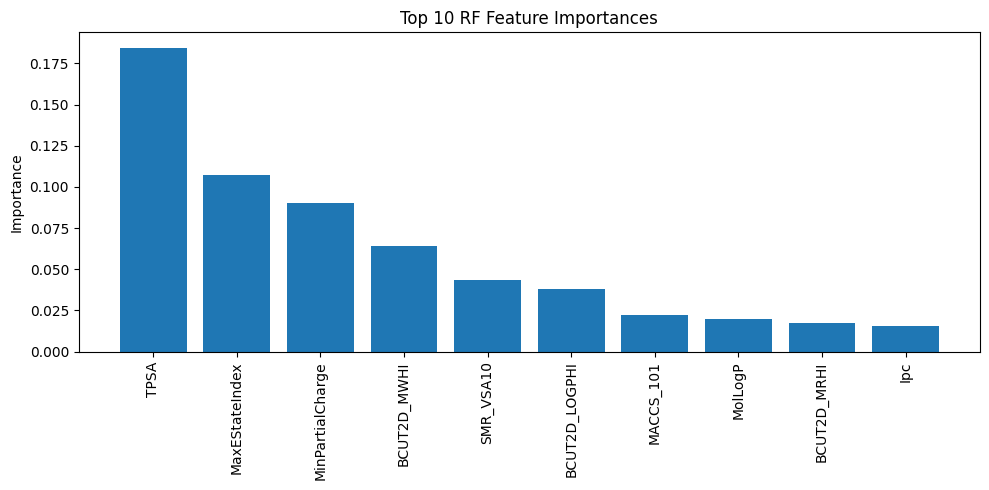

In [12]:
# Feature importance for Random Forest Regressor
importances_rf = best_rf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1][:10]  # Top 10 features
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_rf[indices_rf])
plt.xticks(range(10), X_train.columns[indices_rf], rotation=90)
plt.title("Top 10 RF Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## SVR

In [13]:
# Support Vector Regression (SVR) model
param_grid = {"C": [0.1, 1, 10, 100], "epsilon": [0.01, 0.1, 0.2, 0.5], "kernel": ["rbf", "linear"], "gamma": ["scale", "auto"]}

svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_svr = grid_search.best_estimator_

Best parameters: {'C': 1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}


In [14]:
# svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr = best_svr
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

# Inverse transform predictions and targets
y_test_exp_svr = np.power(10, y_test)
y_pred_exp_svr = np.power(10, y_pred_svr)
print("SVR metrics:")
output_metrics(y_test_exp_svr, y_pred_exp_svr)

SVR metrics:
R2: 0.799
MAE: 175.643
MSE: 91677.914
RMSE: 302.784
Explained Variance: 0.818
RMSE: 302.784
Explained Variance: 0.818
RMSE: 302.784
Explained Variance: 0.818


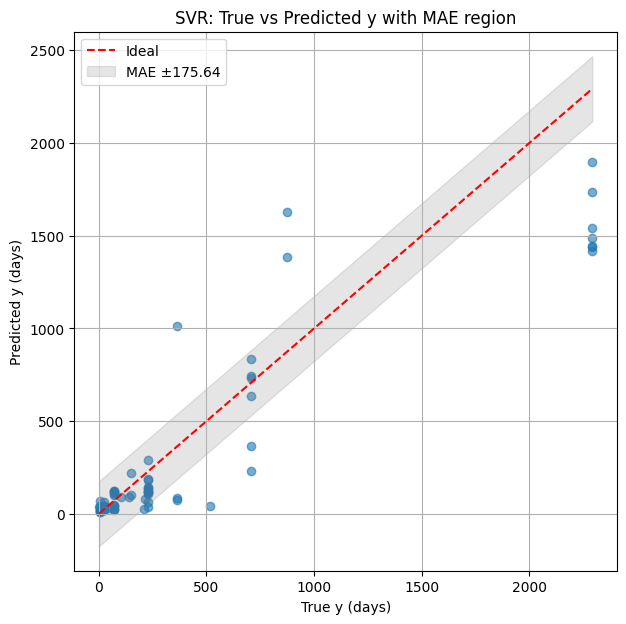

In [15]:
# SVR true vs predicted plot
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
plt.scatter(y_test_exp_svr, y_pred_exp_svr, alpha=0.6)
plt.plot([min(y_test_exp_svr), max(y_test_exp_svr)], [min(y_test_exp_svr), max(y_test_exp_svr)], "r--", label="Ideal")
plt.fill_between(
    [min(y_test_exp_svr), max(y_test_exp_svr)],
    [min(y_test_exp_svr) + mae, max(y_test_exp_svr) + mae],
    [min(y_test_exp_svr) - mae, max(y_test_exp_svr) - mae],
    color="gray",
    alpha=0.2,
    label=f"MAE ±{mae:.2f}",
)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region")
plt.legend()
plt.grid(True)
plt.show()

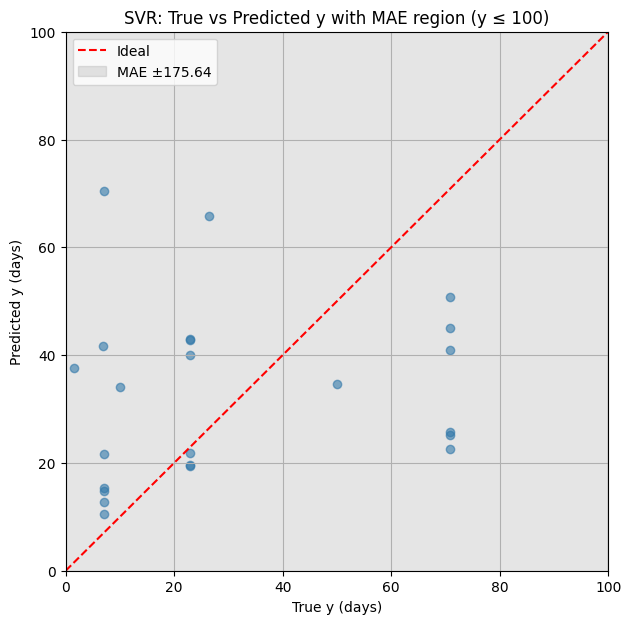

In [16]:
# Add shaded region for MAE to SVR true vs predicted plot, limited to x/y <= 100
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_exp_svr, y_pred_exp_svr)
plt.figure(figsize=(7, 7))
# Only plot points where both true and predicted are <= 100
mask = (y_test_exp_svr <= 100) & (y_pred_exp_svr <= 100)
plt.scatter(y_test_exp_svr[mask], y_pred_exp_svr[mask], alpha=0.6)
plt.plot([0, 100], [0, 100], "r--", label="Ideal")
plt.fill_between([0, 100], [mae, 100 + mae], [-mae, 100 - mae], color="gray", alpha=0.2, label=f"MAE ±{mae:.2f}")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("True y (days)")
plt.ylabel("Predicted y (days)")
plt.title("SVR: True vs Predicted y with MAE region (y ≤ 100)")
plt.legend()
plt.grid(True)
plt.show()

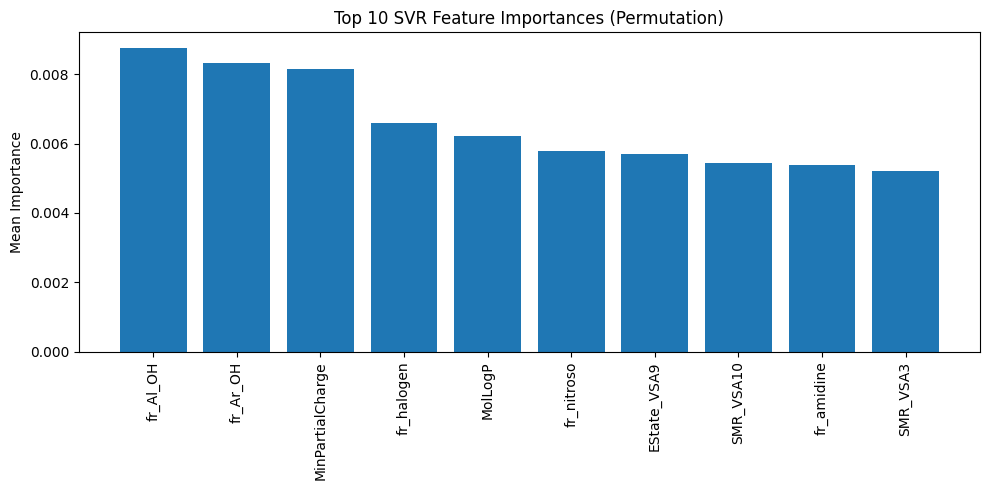

In [17]:
# Plot top ten features by permutation importance for SVR
from sklearn.inspection import permutation_importance

result = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42, scoring="neg_mean_squared_error")
importances = result.importances_mean
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices])
plt.xticks(range(10), X_test.columns[indices], rotation=90)
plt.title("Top 10 SVR Feature Importances (Permutation)")
plt.ylabel("Mean Importance")
plt.tight_layout()
plt.show()

### Bayesian

In [18]:
# Bayesian Ridge Regression with GridSearchCV
param_grid = {
    "alpha_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "alpha_2": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_2": [1e-6, 1e-5, 1e-4, 1e-3],
}

bayes_reg = BayesianRidge()
grid_search = GridSearchCV(bayes_reg, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha_1': 1e-06, 'alpha_2': 0.001, 'lambda_1': 0.001, 'lambda_2': 1e-06}


R2: 0.319
MAE: 265.078
MSE: 310626.737
RMSE: 557.339
Explained Variance: 0.324
RMSE: 557.339
Explained Variance: 0.324
RMSE: 557.339
Explained Variance: 0.324


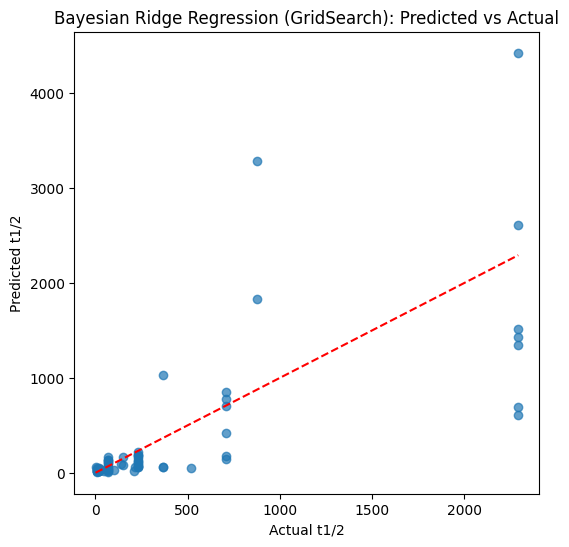

In [19]:
y_pred = grid_search.predict(X_test)

y_test_exp_bayes = np.power(10, y_test)
y_pred_exp_bayes = np.power(10, y_pred)
output_metrics(y_test_exp_bayes, y_pred_exp_bayes)

# Optional: plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_exp_bayes, y_pred_exp_bayes, alpha=0.7)
plt.xlabel("Actual t1/2")
plt.ylabel("Predicted t1/2")
plt.title("Bayesian Ridge Regression (GridSearch): Predicted vs Actual")
plt.plot([y_test_exp_bayes.min(), y_test_exp_bayes.max()], [y_test_exp_bayes.min(), y_test_exp_bayes.max()], "r--")
plt.show()

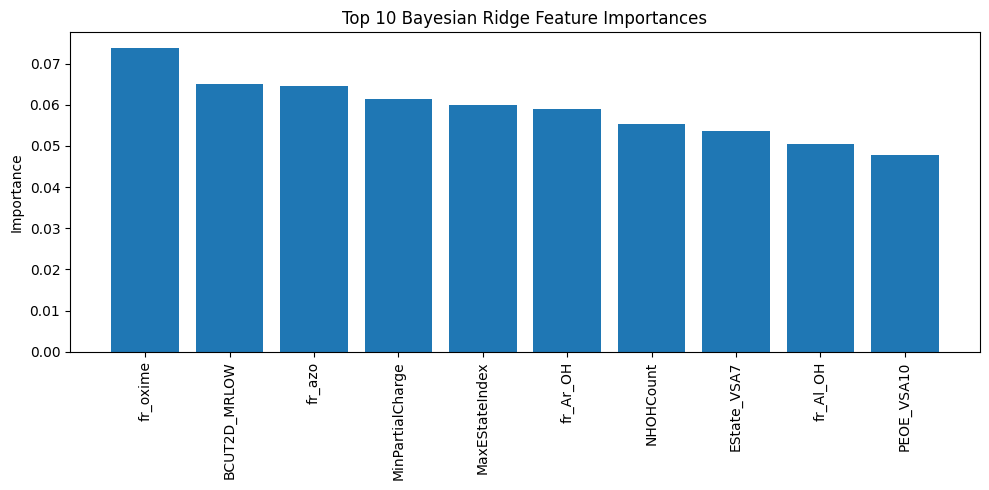

In [20]:
# Extract top 10 features by absolute coefficient value from Bayesian Ridge
importances_bayes = np.abs(grid_search.best_estimator_.coef_)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx = np.argsort(importances_bayes)[-10:][::-1]
top_features = [(feature_names[i], importances_bayes[i]) for i in top_idx]
# print('Top 10 features (by absolute coefficient):')
# for name, val in top_features:
#     print(f'{name}: {val:.4f})' )

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_bayes[top_idx])
plt.xticks(range(10), X_train.columns[top_idx], rotation=90)
plt.title("Top 10 Bayesian Ridge Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### XGBOOST

In [21]:
# XGBOOST with GridSearchCV for hyperparameter tuning
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
}
# Use negative root mean squared error as scoring (available in sklearn 1.7.0)
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2, error_score="raise"
)
grid_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.7; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=4, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END 

R2: 0.636
MAE: 190.289
MSE: 166087.845
RMSE: 407.539
Explained Variance: 0.680
RMSE: 407.539
Explained Variance: 0.680
RMSE: 407.539
Explained Variance: 0.680


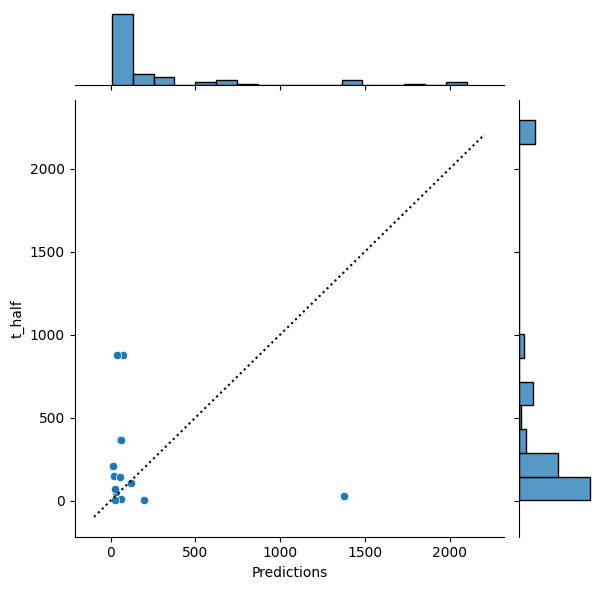

In [22]:
# Predict and evaluate XGBoost with best parameters from GridSearchCV
y_pred = grid_search_xgb.predict(X_test)
y_test_xgboost = np.power(10, y_test)
y_pred_xgboost = np.power(10, y_pred)
output_metrics(y_test_xgboost, y_pred_xgboost)
data = pd.concat([pd.Series(y_pred_xgboost), pd.Series(y_test_xgboost)], axis=1)
data.columns = ["Predictions", "t_half"]

g = sns.jointplot(x="Predictions", y="t_half", data=data)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, ":k")

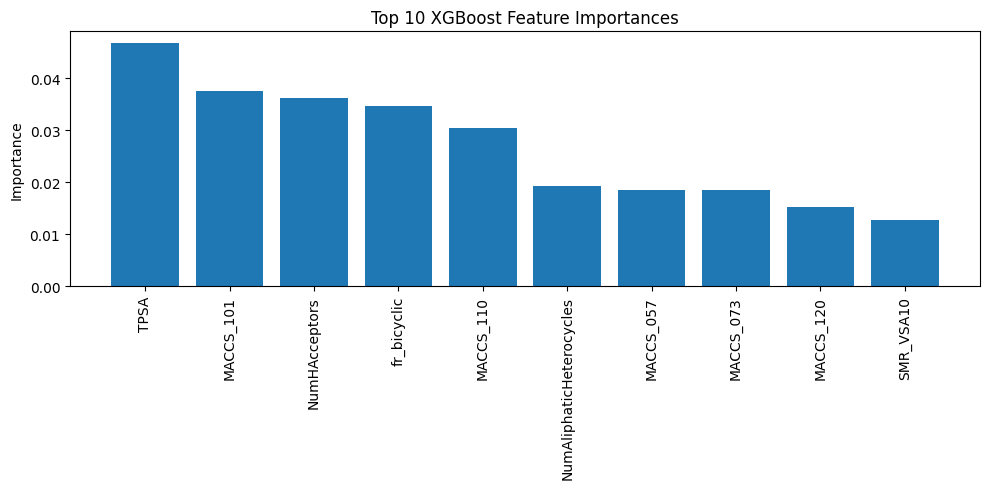

In [23]:
# Extract top 10 features by importance from XGBoost
importances_xgb = grid_search_xgb.best_estimator_.feature_importances_
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx_xgb = np.argsort(importances_xgb)[-10:][::-1]
top_features_xgb = [(feature_names[i], importances_xgb[i]) for i in top_idx_xgb]
# print('Top 10 XGBoost features (by importance):')
# for name, val in top_features_xgb:
#     print(f'{name}: {val:.4f}')

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_xgb[top_idx_xgb])
plt.xticks(range(10), [feature_names[i] for i in top_idx_xgb], rotation=90)
plt.title("Top 10 XGBoost Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()